>Observações: Recomendo fortemente o uso do Google Colab com uma máquina TPU (preferencialmente) ou GPU pois algumas etapas são custosas computacionalmente. As dependências usadas aqui não estão no Poetry do projeto (uma vez que rodei no Colab).

# Aula Prática: Redes Perceptron Multicamadas (PMC)

Nesta prática, vamos construir e treinar uma Rede Perceptron Multicamadas (PMC). Nosso objetivo é resolver um problema com classes não linearmente separáveis utilizando o dataset artificial `make_moons`.

## 1. Instalação, Geração e Normalização dos Dados
Primeiro, vamos instalar o `keras-tuner`. Em seguida, geramos os dados, dividimos em treino e teste, e aplicamos a normalização. A normalização garante que as variáveis tenham a mesma escala, o que é fundamental para o algoritmo do gradiente descendente.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 803.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 38.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


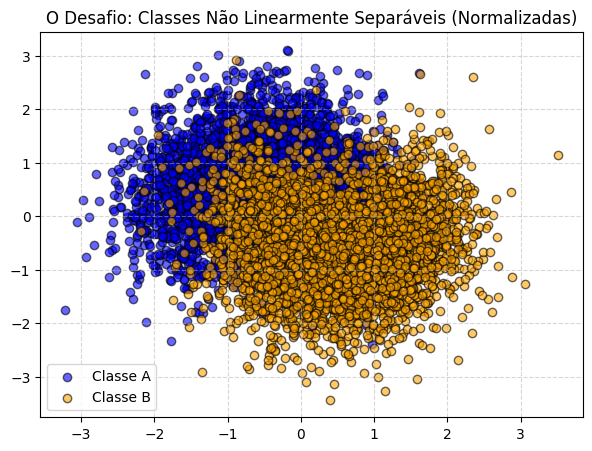

In [2]:
!pip install keras-tuner tensorflow -q

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt

# Gerando o dataset não linear
X_moons, y_moons = make_moons(n_samples=10000, noise=0.5)

# Divisão em Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.2)

# Normalização (Padronização)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Visualização do desafio
plt.figure(figsize=(7, 5))
plt.scatter(X_train_scaled[y_train==0][:, 0], X_train_scaled[y_train==0][:, 1], color='blue', label='Classe A', alpha=0.6, edgecolors='k')
plt.scatter(X_train_scaled[y_train==1][:, 0], X_train_scaled[y_train==1][:, 1], color='orange', label='Classe B', alpha=0.6, edgecolors='k')
plt.title("O Desafio: Classes Não Linearmente Separáveis (Normalizadas)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 2. Abordagem Manual: Construindo a Rede na "Tentativa e Erro"
A topologia da rede (número de neurônios e camadas) pode ser definida de maneira empírica. Vamos começar testando manualmente uma rede com apenas 10 neurônios na camada oculta e uma taxa de aprendizagem padrão para observar o comportamento.

Iniciando treinamento da configuração manual (150 épocas)...
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8066 - loss: 0.4423 - val_accuracy: 0.8081 - val_loss: 0.4216
Epoch 2/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8100 - loss: 0.4212 - val_accuracy: 0.8062 - val_loss: 0.4138
Epoch 3/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8152 - loss: 0.4144 - val_accuracy: 0.8081 - val_loss: 0.4164
Epoch 4/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8147 - loss: 0.4121 - val_accuracy: 0.8100 - val_loss: 0.4072
Epoch 5/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8155 - loss: 0.4101 - val_accuracy: 0.8125 - val_loss: 0.4055
Epoch 6/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8145 - loss: 0.4094 - val_accuracy: 0.8075 - val_loss: 0.4067
Epoch 7/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8178 - loss: 0.4090 - val_accuracy: 0.8131 - val_loss: 0.4034
Epoch 8/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8156 - loss: 0.4100 - val_accuracy: 0.8106

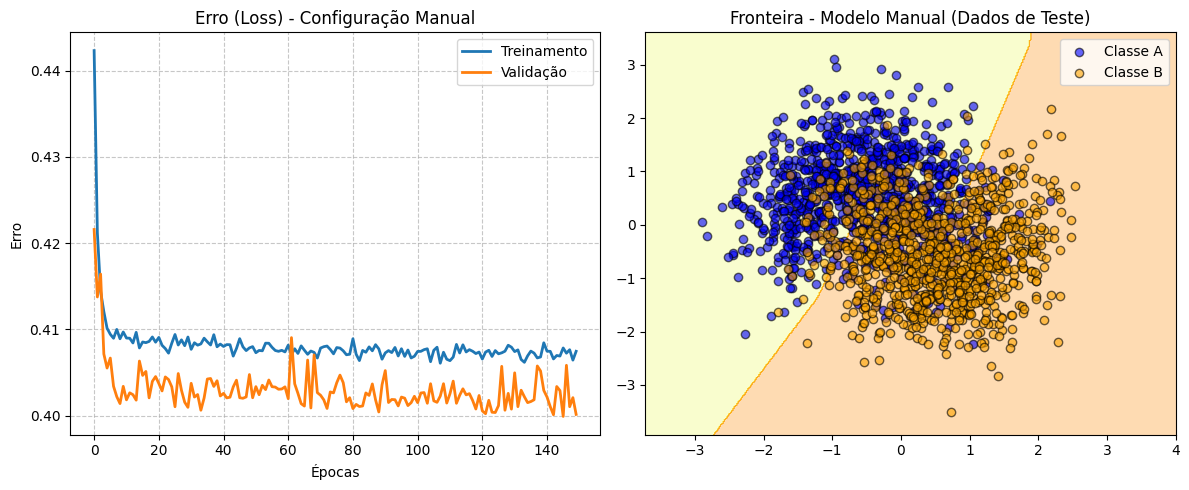

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 651us/step

=== Relatório de Classificação (Modelo Manual) ===
              precision    recall  f1-score   support

    Classe A       0.83      0.82      0.82      1026
    Classe B       0.81      0.82      0.81       974

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



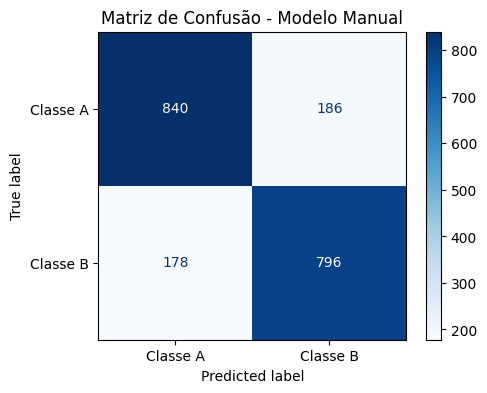

In [3]:
# 1. Definindo a topologia manualmente (chute de 10 neurônios)
modelo_manual = Sequential()
modelo_manual.add(Dense(10, activation='relu', input_shape=(2,)))
modelo_manual.add(Dense(1, activation='sigmoid'))

# Compilando e treinando
modelo_manual.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])

# 2. Configurando os Callbacks
#early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
#reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1)

print("Iniciando treinamento da configuração manual (150 épocas)...")
history_manual = modelo_manual.fit(X_train_scaled, y_train, validation_split=0.2, epochs=150, batch_size=32, verbose=1) #callbacks=[reduce_lr, early_stop])

# 2. Avaliação Visual Rápida (Loss e Fronteira)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_manual.history['loss'], label='Treinamento', linewidth=2)
plt.plot(history_manual.history['val_loss'], label='Validação', linewidth=2)
plt.title("Erro (Loss) - Configuração Manual")
plt.xlabel("Épocas")
plt.ylabel("Erro")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = modelo_manual.predict(np.c_[xx.ravel(), yy.ravel()], verbose=1)
Z = (Z > 0.5).astype(int).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='Wistia')
plt.scatter(X_test_scaled[y_test==0][:, 0], X_test_scaled[y_test==0][:, 1], color='blue', alpha=0.6, edgecolors='k', label='Classe A')
plt.scatter(X_test_scaled[y_test==1][:, 0], X_test_scaled[y_test==1][:, 1], color='orange', alpha=0.6, edgecolors='k', label='Classe B')
plt.title("Fronteira - Modelo Manual (Dados de Teste)")
plt.legend()

plt.tight_layout()
plt.show()

# 3. Métricas e Matriz de Confusão do Modelo Manual
y_pred_probs_manual = modelo_manual.predict(X_test_scaled, verbose=1)
y_pred_classes_manual = (y_pred_probs_manual > 0.5).astype(int)

print("\n=== Relatório de Classificação (Modelo Manual) ===")
print(classification_report(y_test, y_pred_classes_manual, target_names=['Classe A', 'Classe B']))

cm_manual = confusion_matrix(y_test, y_pred_classes_manual)
disp_manual = ConfusionMatrixDisplay(confusion_matrix=cm_manual, display_labels=['Classe A', 'Classe B'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_manual.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Matriz de Confusão - Modelo Manual")
plt.show()

## O que realmente é esse "Gráfico de Fronteira"? É a função da Rede?

Uma dúvida muito comum (e de altíssimo nível) é: *A linha curva que vemos no gráfico é a função real que a rede neural aprendeu?*

A resposta é **Sim!** Esse gráfico é a projeção visual (um "mapa de calor") da matemática complexa que a Rede Perceptron Multicamadas (PMC) construiu. Veja como isso funciona "por baixo dos panos":

**1. A Matemática (A Função Real)**
Como vimos na teoria, um único Perceptron cria apenas uma separação linear (uma reta, plano ou hiperplano), descrita pela equação $X\cdot W+b=0$. Porém, a PMC utiliza as **camadas ocultas** para fazer vários cortes lineares simultâneos e, em seguida, os combina usando **funções de ativação não lineares** (como a sigmoide, representada por $g(.)$) O resultado é uma gigantesca equação matemática que consegue contornar e separar classes não linearmente separáveis.

**2. Como transformamos Matemática em Gráfico? (O Truque do Código)**
Como a equação da rede neural é muito complexa para desenharmos diretamente, nós usamos a força bruta computacional:
* **A Malha (`meshgrid`):** Criamos milhares de pontos artificiais cobrindo todo o fundo da imagem, milímetro por milímetro.
* **A Inferência (`predict`):** Passamos todos esses pontos pela nossa rede já treinada. Ela resolve a equação para cada ponto e nos devolve uma probabilidade (entre $0$ e $1$).
* **A Pintura (`contourf`):** Dizemos ao código: *"Se o resultado for $>0.5$, pinte de laranja. Se for $\le 0.5$, pinte de azul"*.

A linha exata onde a cor muda é a nossa **Fronteira de Decisão**.

### Os Desafios da Abordagem Manual
Como pudemos observar, definir os parâmetros manualmente pode levar a configurações subótimas. Se a rede decora o treino e perde a capacidade de generalização, caímos no fenômeno de *overfitting*. Se ela não consegue mapear a complexidade, ocorre o *underfitting*.

Para resolver isso de forma profissional, usaremos o **Keras Tuner** com **Validação Cruzada ($k$-fold)** para encontrar a arquitetura perfeita, e **Callbacks** para parar o treinamento no momento exato de menor erro de validação.

## 3. Validação Cruzada Customizada com Keras Tuner
Como vimos, a abordagem manual pode ser subótima. Para automatizar a busca, usaremos o **Keras Tuner** acoplado a uma **Validação Cruzada ($k$-fold)**. A rede será treinada em diferentes partições de dados, e a melhor arquitetura será escolhida com base na média de acertos, garantindo alta generalização.

In [4]:
# 1. Função construtora Dinâmica (Camadas e Neurônios)
def build_model(hp):
    model = Sequential()

    # Hiperparâmetro para o número de camadas ocultas (ex: de 1 a 3 camadas)
    num_layers = hp.Int('num_layers', min_value=1, max_value=3, step=1)

    # Adicionando as camadas ocultas dinamicamente
    for i in range(num_layers):
        # Hiperparâmetro de neurônios independente para CADA camada oculta
        hp_units = hp.Int(f'units_{i}', min_value=5, max_value=30, step=5)

        # A primeira camada sempre precisa do input_shape
        if i == 0:
            model.add(Dense(units=hp_units, activation='relu', input_shape=(2,)))
        else:
            model.add(Dense(units=hp_units, activation='relu'))

    # Camada de saída
    model.add(Dense(1, activation='sigmoid'))

    # Hiperparâmetro para a taxa de aprendizagem
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3])

    model.compile(optimizer=Adam(learning_rate=hp_learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# 2. Tuner com Validação Cruzada (A classe continua a mesma!)
class CVTuner(kt.Tuner):
    def run_trial(self, trial, x, y, batch_size=50, epochs=1):
        cv = KFold(n_splits=3, shuffle=True)
        val_losses, val_accuracies = [], []

        for train_idx, val_idx in cv.split(x):
            model = self.hypermodel.build(trial.hyperparameters)
            model.fit(x[train_idx], y[train_idx], batch_size=batch_size, epochs=epochs, verbose=1)
            loss, accuracy = model.evaluate(x[val_idx], y[val_idx], verbose=1)
            val_losses.append(loss)
            val_accuracies.append(accuracy)

        self.oracle.update_trial(trial.trial_id, {'val_loss': np.mean(val_losses), 'val_accuracy': np.mean(val_accuracies)})

# 3. Instanciando e Rodando a Busca
tuner = CVTuner(
    oracle=kt.oracles.RandomSearchOracle(objective='val_accuracy', max_trials=7),
    hypermodel=build_model, directory='tuner_dir', project_name='mlp_moons_deep', overwrite=True
)

print("Iniciando a busca K-Fold de topologias (k=3)...")
tuner.search(X_train_scaled, y_train, batch_size=32, epochs=50)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# 4. Imprimindo os resultados dinâmicos
print("\n=== Melhor Arquitetura Encontrada ===")
melhor_num_camadas = best_hps.get('num_layers')
print(f"Número de Camadas Ocultas: {melhor_num_camadas}")

for i in range(melhor_num_camadas):
    print(f"Neurônios na Camada {i+1}: {best_hps.get(f'units_{i}')}")

print(f"Taxa de aprendizagem (LR): {best_hps.get('learning_rate')}")

Trial 7 Complete [00h 00m 26s]
val_accuracy: 0.8174986243247986

Best val_accuracy So Far: 0.8174986243247986
Total elapsed time: 00h 03m 15s

=== Melhor Arquitetura Encontrada ===
Número de Camadas Ocultas: 1
Neurônios na Camada 1: 15
Taxa de aprendizagem (LR): 0.001


## 4. Treinamento Campeão e Avaliação Final
Vamos treinar a rede final utilizando dois **Callbacks** muito importantes:
* **ReduceLROnPlateau:** Reduz a taxa de aprendizagem se o modelo estagnar.
* **EarlyStopping:** Evita o *overfitting* monitorando o momento em que o erro de teste/validação começa a subir.

Por fim, analisaremos as métricas robustas utilizando a **Matriz de Confusão** e o **Relatório de Classificação**.


Iniciando treinamento final com Callbacks...
Epoch 1/500
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7630 - loss: 0.5377 - val_accuracy: 0.8025 - val_loss: 0.4644 - learning_rate: 0.0010
Epoch 2/500
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8080 - loss: 0.4447 - val_accuracy: 0.8037 - val_loss: 0.4288 - learning_rate: 0.0010
Epoch 3/500
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8103 - loss: 0.4300 - val_accuracy: 0.8037 - val_loss: 0.4235 - learning_rate: 0.0010
Epoch 4/500
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8103 - loss: 0.4268 - val_accuracy: 0.8037 - val_loss: 0.4214 - learning_rate: 0.0010
Epoch 5/500
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8103 - loss: 0.4249 - val_accuracy: 0.8062 - val_loss: 0.4198 - learning_rate: 0.0010
Epoch 6/500
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8111 - loss: 0.4232 - val_accuracy: 0.8069 - val_loss: 0.4183 - learning_rate: 0.0010
Epoch 7/500
200/200 ━━━━━━━━━━━━━━━━

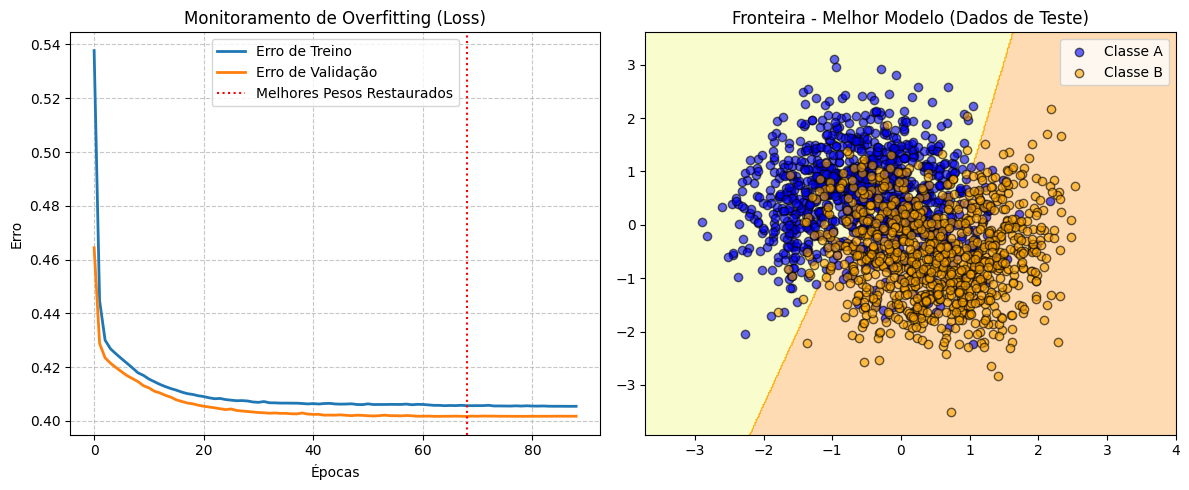


=== Relatório de Classificação (Melhor Modelo) ===
              precision    recall  f1-score   support

    Classe A       0.82      0.82      0.82      1026
    Classe B       0.81      0.81      0.81       974

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



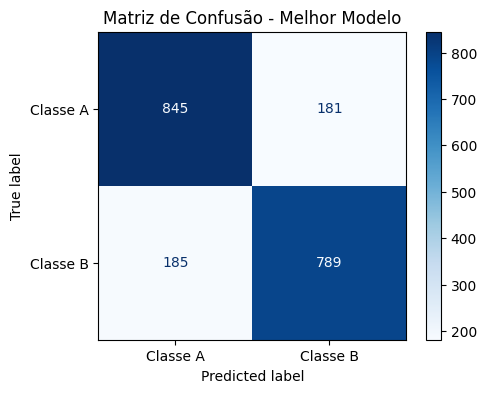

In [5]:
# 1. Construindo o modelo campeão a partir do Tuner
model = tuner.hypermodel.build(best_hps)

# 2. Configurando os Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-4, verbose=1)

print("\nIniciando treinamento final com Callbacks...")
history = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=500, batch_size=32, callbacks=[reduce_lr, early_stop], verbose=1)

# 3. Gráfico de Loss e Early Stopping
plt.figure(figsize=(12, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Erro de Treino', linewidth=2)
plt.plot(history.history['val_loss'], label='Erro de Validação', linewidth=2)
if early_stop.stopped_epoch > 0:
    plt.axvline(x=early_stop.stopped_epoch - early_stop.patience, color='red', linestyle=':', label='Melhores Pesos Restaurados')
plt.title("Monitoramento de Overfitting (Loss)")
plt.xlabel("Épocas")
plt.ylabel("Erro")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Fronteira de Decisão do Melhor Modelo
plt.subplot(1, 2, 2)
Z_best = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
Z_best = (Z_best > 0.5).astype(int).reshape(xx.shape)

plt.contourf(xx, yy, Z_best, alpha=0.3, cmap='Wistia')
plt.scatter(X_test_scaled[y_test==0][:, 0], X_test_scaled[y_test==0][:, 1], color='blue', alpha=0.6, edgecolors='k', label='Classe A')
plt.scatter(X_test_scaled[y_test==1][:, 0], X_test_scaled[y_test==1][:, 1], color='orange', alpha=0.6, edgecolors='k', label='Classe B')
plt.title("Fronteira - Melhor Modelo (Dados de Teste)")
plt.legend()

plt.tight_layout()
plt.show()

# 4. Avaliação e Métricas nos Dados Inéditos
y_pred_probs = model.predict(X_test_scaled, verbose=0)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

print("\n=== Relatório de Classificação (Melhor Modelo) ===")
print(classification_report(y_test, y_pred_classes, target_names=['Classe A', 'Classe B']))

# 5. Matriz de Confusão do Melhor Modelo
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe A', 'Classe B'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Matriz de Confusão - Melhor Modelo")
plt.show()

# Exercício 01

Voltem na etapa de Treinamento Manual e substituam a função de ativação das camadas ocultas de activation='sigmoid' para activation='tanh' e depois para activation='relu'. A camada de saída deve continuar como sigmoid (pois é uma classificação binária). Não faça outras alterações na rede nesse momento. Observem o comportamento das curvas de perda e no gráfico de fronteira. Que conclusões é possível tirar?

Iniciando treinamento
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7930 - loss: 0.4520 - val_accuracy: 0.8025 - val_loss: 0.4260
Epoch 2/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8106 - loss: 0.4258 - val_accuracy: 0.8069 - val_loss: 0.4150
Epoch 3/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8142 - loss: 0.4189 - val_accuracy: 0.8106 - val_loss: 0.4098
Epoch 4/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8116 - loss: 0.4159 - val_accuracy: 0.8112 - val_loss: 0.4080
Epoch 5/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8125 - loss: 0.4143 - val_accuracy: 0.8094 - val_loss: 0.4042
Epoch 6/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8161 - loss: 0.4136 - val_accuracy: 0.8044 - val_loss: 0.4053
Epoch 7/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8133 - loss: 0.4135 - val_accuracy: 0.8069 - val_loss: 0.4040
Epoch 8/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8134 - loss: 0.4136 - val_accuracy: 0.8163

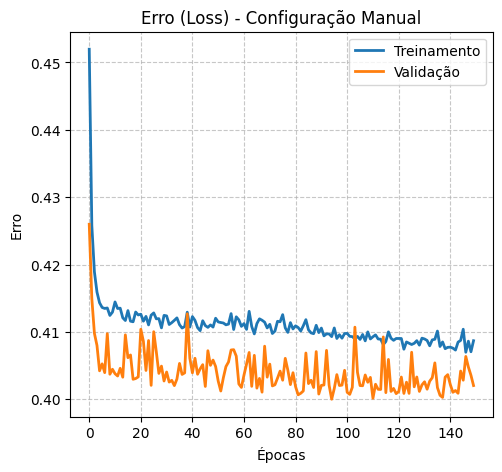

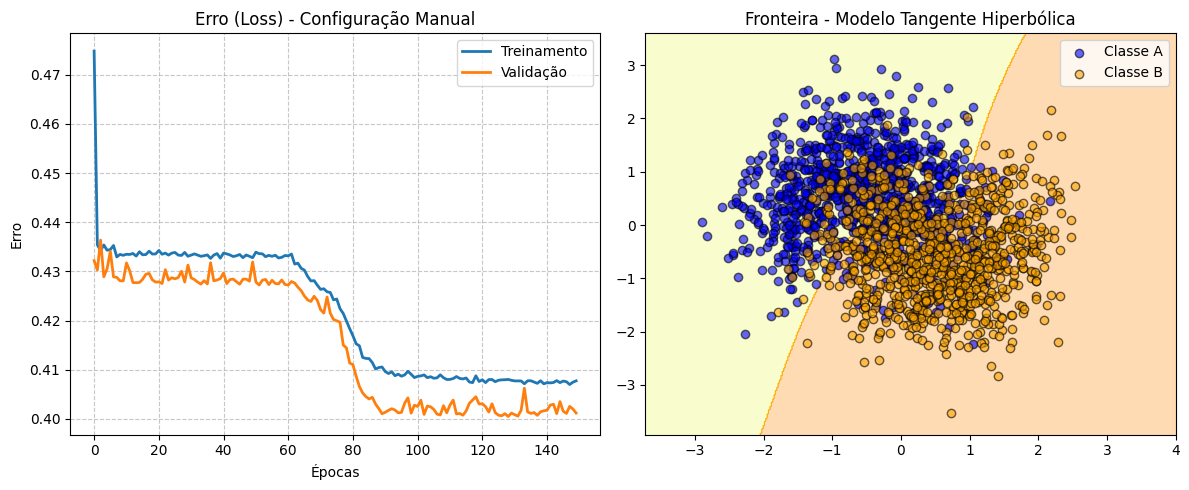

4572/4572 ━━━━━━━━━━━━━━━━━━━━ 2s 500us/step


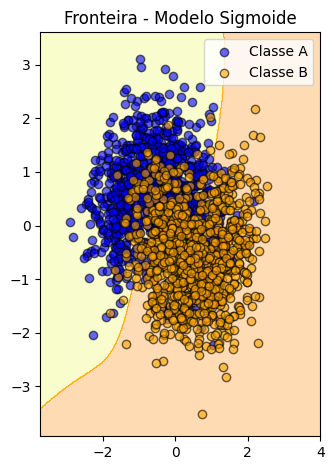

In [8]:
modelo_tanh = Sequential()
modelo_tanh.add(Dense(10, activation='tanh', input_shape=(2,)))
modelo_tanh.add(Dense(1, activation='sigmoid'))

modelo_sigmoid = Sequential()
modelo_sigmoid.add(Dense(10, activation='sigmoid', input_shape=(2,)))
modelo_sigmoid.add(Dense(1, activation='sigmoid'))

# Compilando e treinando
modelo_tanh.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])
modelo_sigmoid.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])

print("Iniciando treinamento")
history_tanh = modelo_tanh.fit(X_train_scaled, y_train, validation_split=0.2, epochs=150, batch_size=32, verbose=1)
history_sigmoid = modelo_sigmoid.fit(X_train_scaled, y_train, validation_split=0.2, epochs=150, batch_size=32, verbose=1)

4572/4572 ━━━━━━━━━━━━━━━━━━━━ 2s 498us/step


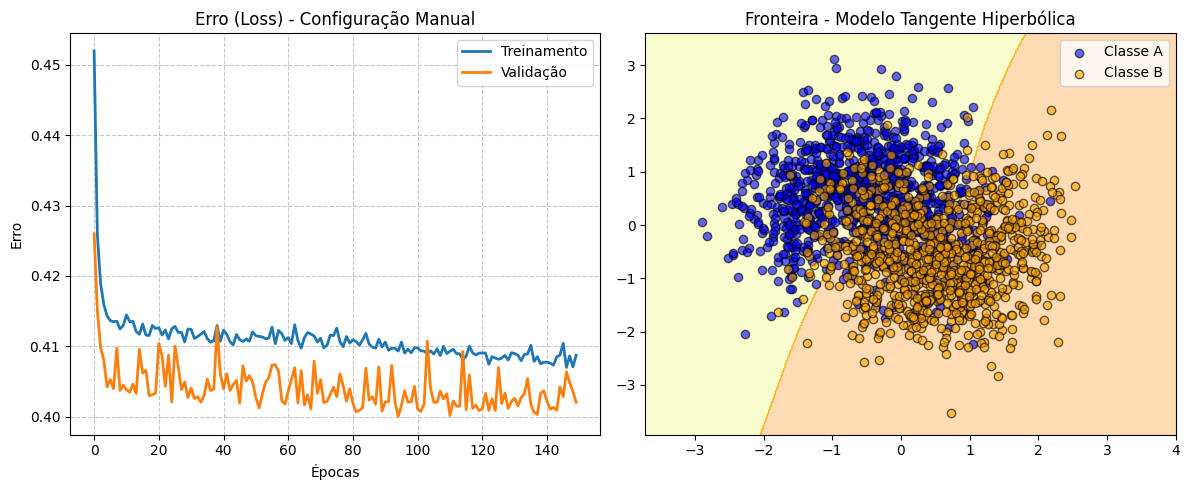

4572/4572 ━━━━━━━━━━━━━━━━━━━━ 2s 458us/step


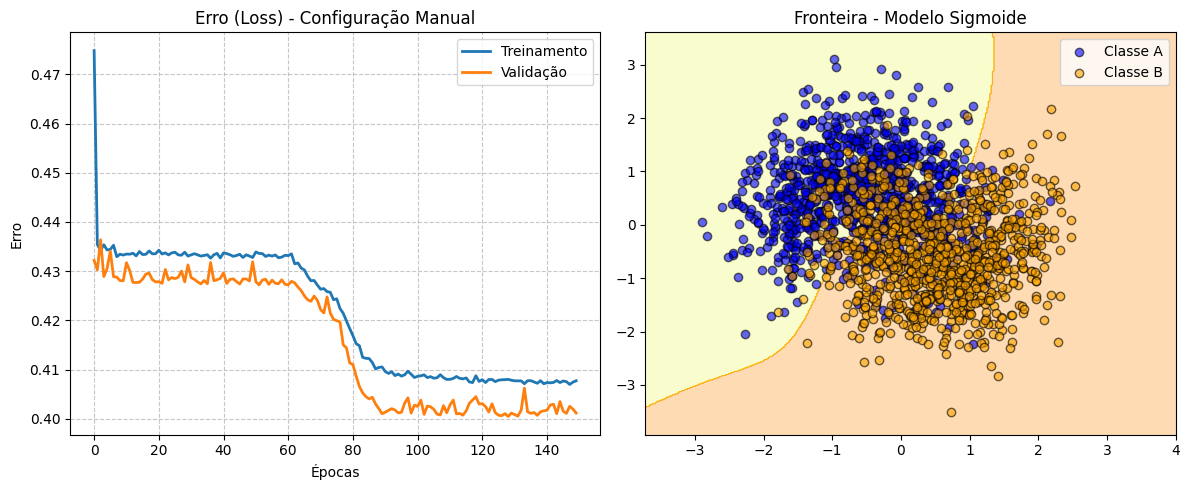

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_tanh.history['loss'], label='Treinamento', linewidth=2)
plt.plot(history_tanh.history['val_loss'], label='Validação', linewidth=2)
plt.title("Erro (Loss) - Configuração Manual")
plt.xlabel("Épocas")
plt.ylabel("Erro")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z_tanh = modelo_tanh.predict(np.c_[xx.ravel(), yy.ravel()], verbose=1)
Z_tanh = (Z_tanh > 0.5).astype(int).reshape(xx.shape)

plt.contourf(xx, yy, Z_tanh, alpha=0.3, cmap='Wistia')
plt.scatter(X_test_scaled[y_test==0][:, 0], X_test_scaled[y_test==0][:, 1], color='blue', alpha=0.6, edgecolors='k', label='Classe A')
plt.scatter(X_test_scaled[y_test==1][:, 0], X_test_scaled[y_test==1][:, 1], color='orange', alpha=0.6, edgecolors='k', label='Classe B')
plt.title("Fronteira - Modelo Tangente Hiperbólica")
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_sigmoid.history['loss'], label='Treinamento', linewidth=2)
plt.plot(history_sigmoid.history['val_loss'], label='Validação', linewidth=2)
plt.title("Erro (Loss) - Configuração Manual")
plt.xlabel("Épocas")
plt.ylabel("Erro")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
Z_sigmoid = modelo_sigmoid.predict(np.c_[xx.ravel(), yy.ravel()], verbose=1)
Z_sigmoid = (Z_sigmoid > 0.5).astype(int).reshape(xx.shape)

plt.contourf(xx, yy, Z_sigmoid, alpha=0.3, cmap='Wistia')
plt.scatter(X_test_scaled[y_test==0][:, 0], X_test_scaled[y_test==0][:, 1], color='blue', alpha=0.6, edgecolors='k', label='Classe A')
plt.scatter(X_test_scaled[y_test==1][:, 0], X_test_scaled[y_test==1][:, 1], color='orange', alpha=0.6, edgecolors='k', label='Classe B')
plt.title("Fronteira - Modelo Sigmoide")
plt.legend()

plt.tight_layout()
plt.show()

Conclusão
---
Ainda não consigo explicar, mas percebi que a sigmoide demora mais a convergir.

# Exercício 2

Crie uma nova célula de código copiando a arquitetura manual, mas dessa vez configurando uma rede gigantesca: Dense(100) -> Dense(100) -> Dense(100). Desative o EarlyStopping e o validation_split, treinando por 1000 épocas.
Como ficaram as curvas de perda e o gráfico de fronteira? Houve Overfitting?

Iniciando treinamento da configuração manual (150 épocas)...
Epoch 1/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8052 - loss: 0.4394 - val_accuracy: 0.8025 - val_loss: 0.4192
Epoch 2/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8075 - loss: 0.4239 - val_accuracy: 0.8031 - val_loss: 0.4160
Epoch 3/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8125 - loss: 0.4227 - val_accuracy: 0.8163 - val_loss: 0.4327
Epoch 4/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8108 - loss: 0.4194 - val_accuracy: 0.8056 - val_loss: 0.4120
Epoch 5/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8156 - loss: 0.4173 - val_accuracy: 0.8044 - val_loss: 0.4296
Epoch 6/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8150 - loss: 0.4184 - val_accuracy: 0.8087 - val_loss: 0.4089
Epoch 7/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8125 - loss: 0.4155 - val_accuracy: 0.8138 - val_loss: 0.4203
Epoch 8/1000
200/200 ━━━━━━━━

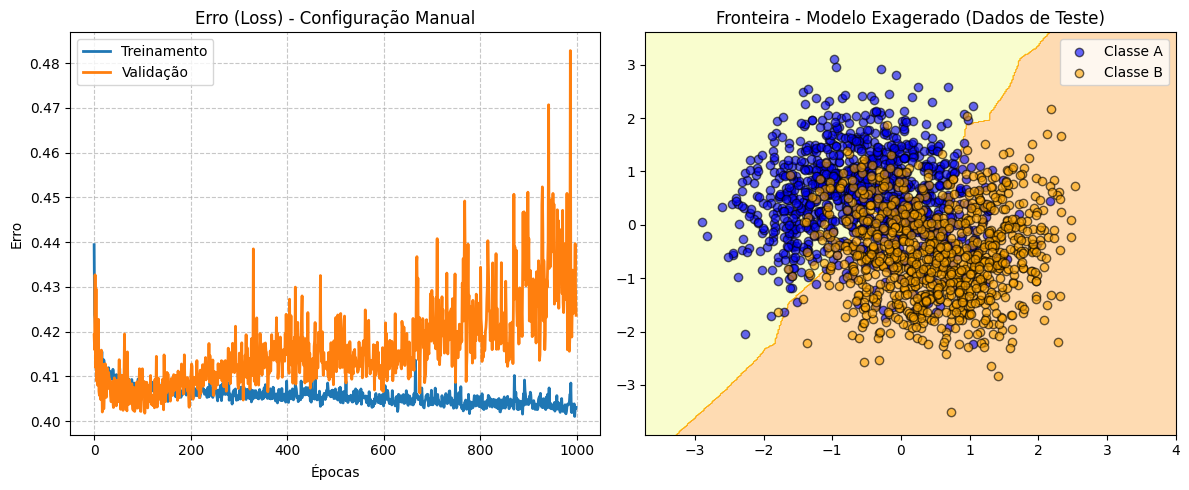

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step

=== Relatório de Classificação (Modelo Exagerado) ===
              precision    recall  f1-score   support

    Classe A       0.84      0.79      0.81      1026
    Classe B       0.79      0.84      0.81       974

    accuracy                           0.81      2000
   macro avg       0.82      0.82      0.81      2000
weighted avg       0.82      0.81      0.81      2000



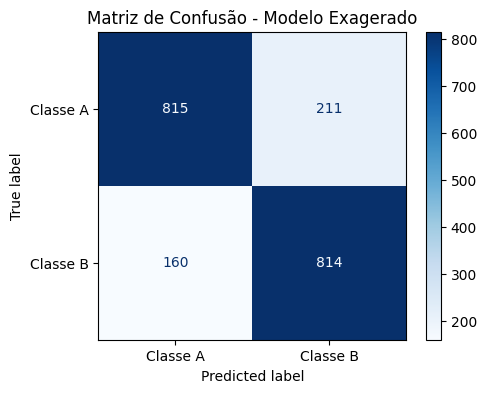

In [7]:
modelo_exagerado = Sequential()
modelo_exagerado.add(Dense(100, activation='relu', input_shape=(2,)))
modelo_exagerado.add(Dense(100, activation='relu'))
modelo_exagerado.add(Dense(100, activation='relu'))
modelo_exagerado.add(Dense(1, activation='sigmoid'))

# Compilando e treinando
modelo_exagerado.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])

print("Iniciando treinamento da configuração manual (150 épocas)...")
history_exagerado = modelo_exagerado.fit(X_train_scaled, y_train, epochs=1000, batch_size=32, verbose=1)

4572/4572 ━━━━━━━━━━━━━━━━━━━━ 2s 498us/step


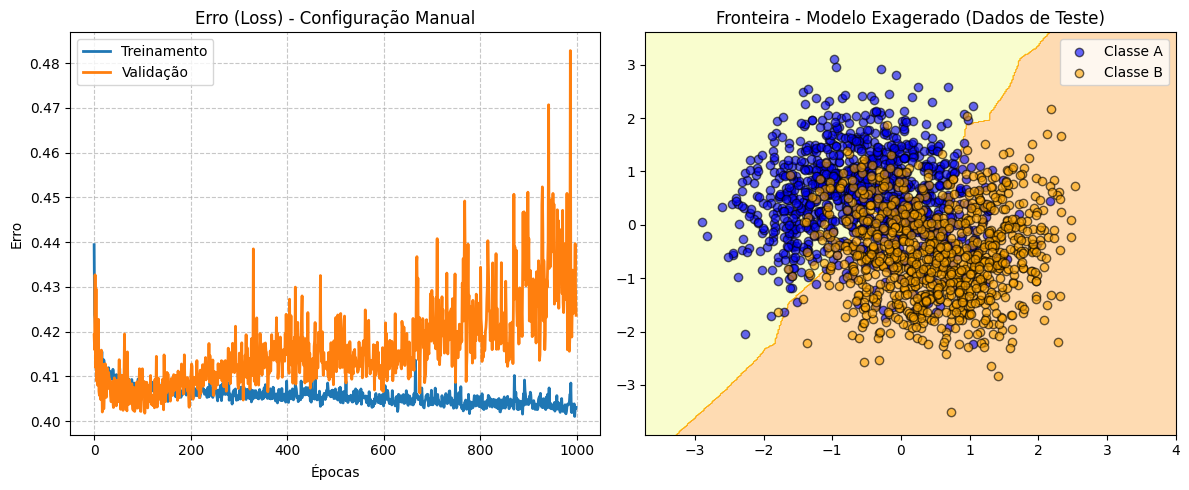

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step

=== Relatório de Classificação (Modelo Exagerado) ===
              precision    recall  f1-score   support

    Classe A       0.84      0.79      0.81      1026
    Classe B       0.79      0.84      0.81       974

    accuracy                           0.81      2000
   macro avg       0.82      0.82      0.81      2000
weighted avg       0.82      0.81      0.81      2000



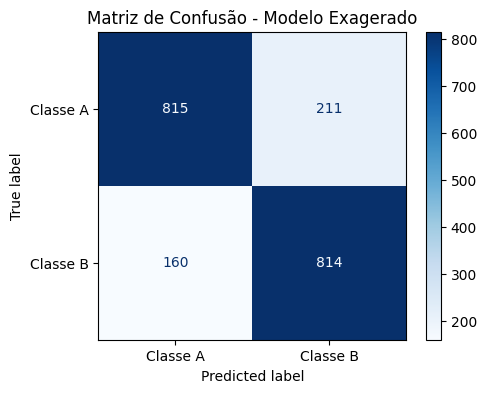

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_exagerado.history['loss'], label='Treinamento', linewidth=2)
plt.plot(history_exagerado.history['val_loss'], label='Validação', linewidth=2)
plt.title("Erro (Loss) - Configuração Manual")
plt.xlabel("Épocas")
plt.ylabel("Erro")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
Z_exagerado = modelo_exagerado.predict(np.c_[xx.ravel(), yy.ravel()], verbose=1)
Z_exagerado = (Z_exagerado > 0.5).astype(int).reshape(xx.shape)

plt.contourf(xx, yy, Z_exagerado, alpha=0.3, cmap='Wistia')
plt.scatter(X_test_scaled[y_test==0][:, 0], X_test_scaled[y_test==0][:, 1], color='blue', alpha=0.6, edgecolors='k', label='Classe A')
plt.scatter(X_test_scaled[y_test==1][:, 0], X_test_scaled[y_test==1][:, 1], color='orange', alpha=0.6, edgecolors='k', label='Classe B')
plt.title("Fronteira - Modelo Exagerado (Dados de Teste)")
plt.legend()

plt.tight_layout()
plt.show()

# 3. Métricas e Matriz de Confusão do Modelo Manual
y_pred_probs_exagerado = modelo_exagerado.predict(X_test_scaled, verbose=1)
y_pred_classes_exagerado = (y_pred_probs_exagerado > 0.5).astype(int)

print("\n=== Relatório de Classificação (Modelo Exagerado) ===")
print(classification_report(y_test, y_pred_classes_exagerado, target_names=['Classe A', 'Classe B']))

cm_exagerado = confusion_matrix(y_test, y_pred_classes_exagerado)
disp_exagerado = ConfusionMatrixDisplay(confusion_matrix=cm_exagerado, display_labels=['Classe A', 'Classe B'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_exagerado.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Matriz de Confusão - Modelo Exagerado")
plt.show()

Conclusão
---
Com certeza houve "overfitting", algumas formas de confirmar são:
- Percebemos que com o passar das épocas, o modelo se torna cada vez mais enviesado (especialista) em determinado dado (os de treino) e acaba perdendo a capacidade de generalizar ao longo do processo;
- No gráfico de fronteiro percebemos uma tentativa de ajuste fino à cada ocorrência dos dados - o que é impossível devido à sua natureza ruidosa - e mesmo assim a falha;
- Algo mudou nas métricas finais, mas não sei explicar como ainda...

# Exercício 3

Altere o parâmetro de Noise do make_moons para 0.1, 0.5 e 0.6. Para cada caso,
Verifique os itens das questões 1 e 2. O que acontece quando o ruído aumenta? E quando diminui?

Observação
---
Não irei realizar mais testes com o ruído superior à 0.5 pois está sendo muito custoso (computacionalmente).

Palpite
---
Sem sombra de dúvidas, ao aumentar o ruído diminuiremos a acurácia do modelo a aumentaremos o ponto de convergência em relação às épocas.